In [1]:
import geogridfusion
import pvdeg

import matplotlib.pyplot as plt
import numpy as np # range generation for bounding box

# open connection to database
conn = geogridfusion.start()

Starting Postgres subprocess...
PostgreSQL connection established after 2.72 seconds.
postgis already installed


Generate coordinate pairs to request

In [ ]:
longitude = [-109.060253, -102.041524]
latitude = [36.992426, 41.003444]

RESOLUTION = 5

lats = np.linspace(latitude[0], latitude[1], RESOLUTION)
lons = np.linspace(longitude[0], longitude[1], RESOLUTION)

lat_grid, lon_grid = np.meshgrid(lats, lons, indexing='ij')
pairs = np.column_stack((lat_grid.ravel(), lon_grid.ravel()))

option a: get weather and store for one location at a time.

In [ ]:
for pair in pairs:
    single_weather, single_meta = pvdeg.weather.get(
        database="PVGIS",
        id=tuple(pair)
    )

    geogridfusion.store_single(conn=conn, weather_df=single_weather, meta=single_meta, tmy=True, source_name="pvgis")

option b: get weather using dask for parallel speedup and write individually after all locations are loaded

In [ ]:
client = pvdeg.geospatial.start_dask()

# this is a required step, otherwis4e the distrubted weather call will raise AttributeError: 'NoneType' object has no attribute 'sizes'
pairs_tuples = [tuple(pair) for pair in pairs]

try:
    geo_weather, geo_meta, failed_idx = pvdeg.weather.weather_distributed(
        database="PVGIS",
        coords=pairs_tuples
    )

except Exception as e:
    client.close()
    raise e

for i, gid in enumerate(geo_weather.gid):
    print(gid)
    geogridfusion.store_single(
        conn=conn,
        weather_df=geo_weather.sel(gid=gid).to_dataframe(),
        meta=geo_meta.iloc[i].to_dict(),
        tmy=True,
        source_name='pvgis'
    )

Load all stored locations from dataset

In [13]:
geogridfusion.sources(conn)

{'era5-reanalysis': 401, 'pvgis': 245}

In [ ]:
loaded_weather, loaded_meta = geogridfusion.load_many(conn=conn, source_name="pvgis")

loaded_weather

Run pvdeg geospatial degradation analysis

In [ ]:
colorado_res = pvdeg.geospatial.analysis(
    weather_ds=loaded_weather,
    meta_df=loaded_meta,
    func=pvdeg.standards.standoff,
)

Plot result of small analysis

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# standoff height
da = colorado_res.x

proj = ccrs.LambertConformal(central_longitude=-96, central_latitude=39)

fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=proj)

ax.set_extent([-125, -66.5, 24, 50], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, zorder=0, edgecolor='face')
ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.6)
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.4)

plot = da.plot(
    ax=ax,
    x='longitude', y='latitude',
    transform=ccrs.PlateCarree(),    # data CRS of the coordinates
    cmap='viridis',
    add_colorbar=True,
    cbar_kwargs={'label': str(da.name) if da.name else 'value'},
)

ax.set_title('PVGIS/Colorado result over CONUS', fontsize=12)
plt.tight_layout()
plt.show()

### But wait, what if we want to do the entire country

In [3]:
from cartopy.io import shapereader
from shapely.ops import unary_union
from shapely import Point

# download n points for the rest of the country
# they could be from the nsrdb instead to demonstrate how we can combine data sources
longitude = [-124,73, -75.46]
latitude = [30, 49]

RESOLUTION = 20

lats = np.linspace(latitude[0], latitude[1], RESOLUTION)
lons = np.linspace(longitude[0], longitude[1], RESOLUTION)

lat_grid, lon_grid = np.meshgrid(lats, lons, indexing='ij')
pairs = np.column_stack((lat_grid.ravel(), lon_grid.ravel()))


# need a quick way to check if we are over land
# could just use a list of predefined points instead
def _build_land_polygon(resolution="110m", shrink=0.0):
    shp_path = shapereader.natural_earth(
        resolution=resolution, category="physical", name="land"
    )
    land = unary_union(list(shapereader.Reader(shp_path).geometries()))
    return land.buffer(-shrink) if shrink else land

_LAND_POLY = _build_land_polygon()

def is_over_land_fast(lat, lon):
    return _LAND_POLY.contains(Point(lon, lat))


pairs_tuples = [tuple(pair) for pair in pairs]
land_pairs = [(lat, lon) for (lat, lon) in pairs_tuples if is_over_land_fast(lat, lon)]

print("started loading weather data")

# get weather for all points on land
try:
    geo_weather, geo_meta, failed_idx = pvdeg.weather.weather_distributed(
        database="PVGIS",
        coords=land_pairs
    )
except Exception as e:
    client.close()
    raise e

print("done loading weather data")

geo_weather = geo_weather.compute() # small dataset fits into memory so remove dask chunks

# save points to geogridfusion
# this is currently the slowest bit because it uses blocking calls when talking to the database
for i, gid in enumerate(geo_weather.gid.values):
    print(gid)
    geogridfusion.store_single(
        conn=conn,
        weather_df=geo_weather.sel(gid=gid).to_dataframe(),
        meta=geo_meta.iloc[i].to_dict(),
        tmy=True,
        source_name='pvgis'
    )

Connected to a Dask scheduler | Dashboard: http://127.0.0.1:8787/status


c:\Users\tford\AppData\Local\miniconda3\envs\geogridfusion\Lib\site-packages\distributed\client.py:3383: UserWarning: Sending large graph of size 133.26 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


0
coercing tmy data to year 1979
duplicate file detected, skipping insert
metadata of duplicate file {'latitude': 30.0, 'longitude': -103.26315789473685, 'irradiance_time_offset': 0.0, 'altitude': 1069.0, 'wind_height': 10, 'Source': 'PVGIS'}
1
coercing tmy data to year 1979
duplicate file detected, skipping insert
metadata of duplicate file {'latitude': 30.0, 'longitude': -92.89473684210526, 'irradiance_time_offset': 0.0, 'altitude': 4.0, 'wind_height': 10, 'Source': 'PVGIS'}
2
coercing tmy data to year 1979
duplicate file detected, skipping insert
metadata of duplicate file {'latitude': 30.0, 'longitude': -82.52631578947368, 'irradiance_time_offset': 0.0, 'altitude': 37.0, 'wind_height': 10, 'Source': 'PVGIS'}
3
coercing tmy data to year 1979
duplicate file detected, skipping insert
metadata of duplicate file {'latitude': 30.0, 'longitude': 0.4210526315789451, 'irradiance_time_offset': 0.1555, 'altitude': 444.0, 'wind_height': 10, 'Source': 'PVGIS'}
4
coercing tmy data to year 1979
d

Load whole country, (show how we can store more points over-time as needs change)

Can demonstrate some downselection here? Or combining of different datasets?

In [5]:
loaded_weather, loaded_meta = geogridfusion.load_many(conn=conn, source_name="pvgis")

Perform same analysis and create a plot for the whole country.

In [6]:
usa_res = pvdeg.geospatial.analysis(
    weather_ds=loaded_weather,
    meta_df=loaded_meta,
    func=pvdeg.standards.standoff
)

The array tilt angle was not provided, therefore the latitude tilt of 37.0 was used.
The array azimuth was not provided, therefore an azimuth of 180.0 was used.
The array tilt angle was not provided, therefore the latitude tilt of 37.0 was used.
The array azimuth was not provided, therefore an azimuth of 180.0 was used.
The array tilt angle was not provided, therefore the latitude tilt of 37.0 was used.
The array azimuth was not provided, therefore an azimuth of 180.0 was used.
The array tilt angle was not provided, therefore the latitude tilt of 37.0 was used.
The array azimuth was not provided, therefore an azimuth of 180.0 was used.
The array tilt angle was not provided, therefore the latitude tilt of 37.0 was used.
The array azimuth was not provided, therefore an azimuth of 180.0 was used.
The array tilt angle was not provided, therefore the latitude tilt of 38.0 was used.
The array azimuth was not provided, therefore an azimuth of 180.0 was used.
The array tilt angle was not provi

Plot expanded dataset/analysis

This plot looks very bad because of the granularity. We could easily just download more points from PVGIS to fill it in.

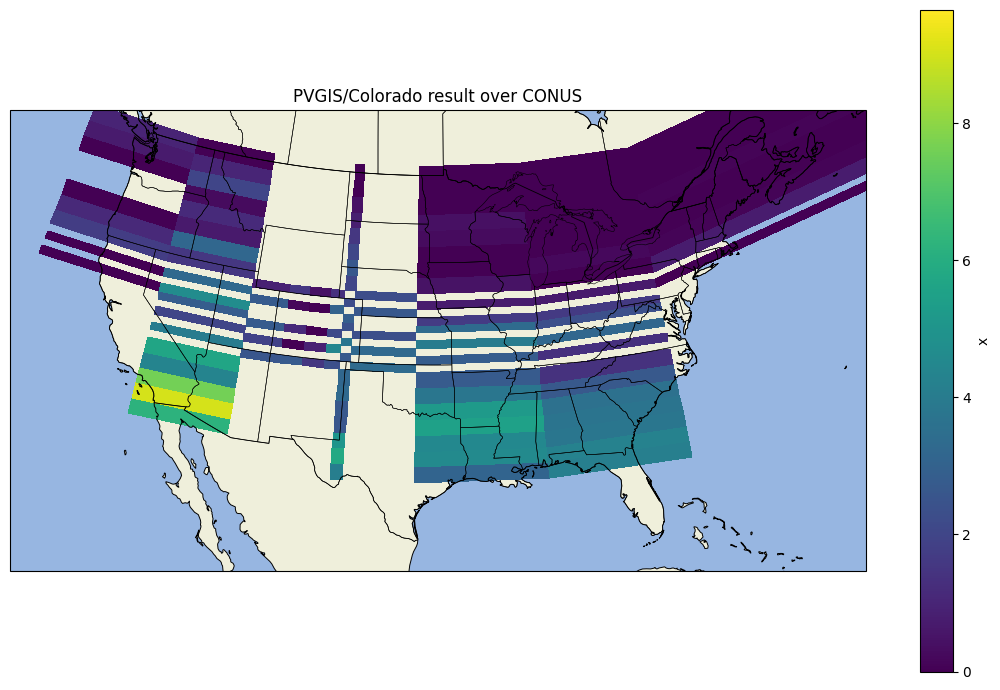

In [9]:
da = usa_res.x

proj = ccrs.LambertConformal(central_longitude=-96, central_latitude=39)

fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=proj)

ax.set_extent([-125, -66.5, 24, 50], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, zorder=0, edgecolor='face')
ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.6)
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.4)

plot = da.plot(
    ax=ax,
    x='longitude', y='latitude',
    transform=ccrs.PlateCarree(),    # data CRS of the coordinates
    cmap='viridis',
    add_colorbar=True,
    cbar_kwargs={'label': str(da.name) if da.name else 'value'},
)

ax.set_title('PVGIS/Colorado result over CONUS', fontsize=12)
plt.tight_layout()
plt.show()